C:\Users\swarn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K-Means Silhouette Score: 0.285
Hierarchical Silhouette Score: 0.277
DBSCAN could not form enough clusters.

Cluster Summary
           alcohol  malic_acid       ash  alcalinity_of_ash   magnesium  \
Cluster                                                                   
0        12.250923    1.897385  2.231231          20.063077   92.738462   
1        13.134118    3.307255  2.417647          21.241176   98.666667   
2        13.676774    1.997903  2.466290          17.462903  107.967742   

         total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
Cluster                                                                     
0             2.247692    2.050000              0.357692         1.624154   
1             1.683922    0.818824              0.451961         1.145882   
2             2.847581    3.003226              0.292097         1.922097   

         color_intensity       hue  od280/od315_of_diluted_wines      proline  \
Cluster                         

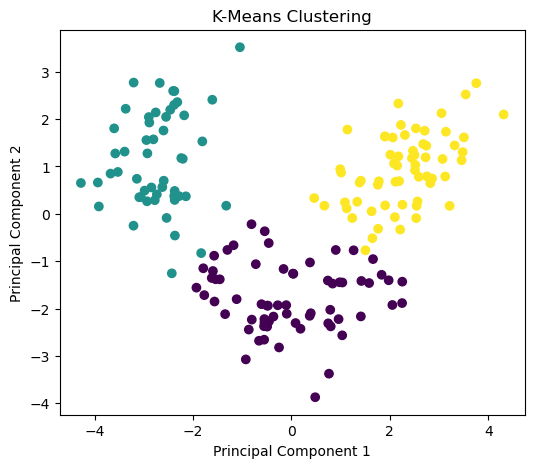

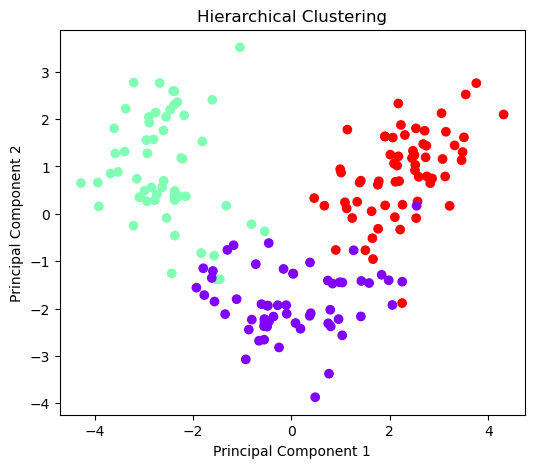

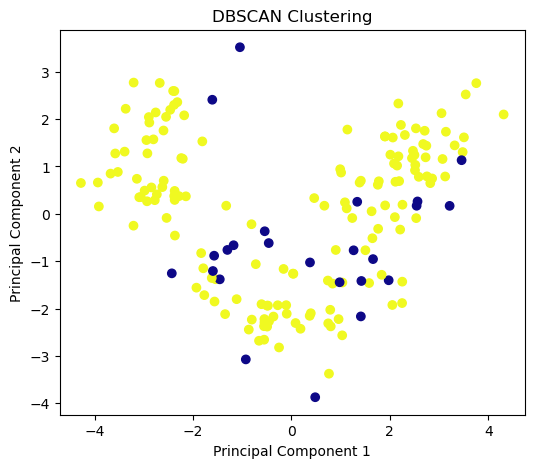


Cluster Interpretation

Cluster 0
alcohol                          12.250923
malic_acid                        1.897385
ash                               2.231231
alcalinity_of_ash                20.063077
magnesium                        92.738462
total_phenols                     2.247692
flavanoids                        2.050000
nonflavanoid_phenols              0.357692
proanthocyanins                   1.624154
color_intensity                   2.973077
hue                               1.062708
od280/od315_of_diluted_wines      2.803385
proline                         510.169231
target                            1.000000
Cluster                           0.000000
dtype: float64

Cluster 1
alcohol                          13.134118
malic_acid                        3.307255
ash                               2.417647
alcalinity_of_ash                21.241176
magnesium                        98.666667
total_phenols                     1.683922
flavanoids                        0.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# -----------------------------
# Load Dataset
# -----------------------------
wine = load_wine(as_frame=True)
df = wine.frame

# Features
X = df.drop("target", axis=1)

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# PCA (Reduce to 2 Dimensions)
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -----------------------------
# K-Means Clustering
# -----------------------------
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means Silhouette Score:",
      round(silhouette_score(X_scaled, kmeans_labels),3))

# -----------------------------
# Hierarchical Clustering
# -----------------------------
hc = AgglomerativeClustering(n_clusters=3)

hc_labels = hc.fit_predict(X_scaled)

print("Hierarchical Silhouette Score:",
      round(silhouette_score(X_scaled, hc_labels),3))

# -----------------------------
# DBSCAN Clustering
# -----------------------------
dbscan = DBSCAN(eps=2.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    print("DBSCAN Silhouette Score:",
          round(silhouette_score(X_scaled[mask],
                                 dbscan_labels[mask]),3))
else:
    print("DBSCAN could not form enough clusters.")

# -----------------------------
# Add Cluster Labels
# -----------------------------
df["Cluster"] = kmeans_labels

# -----------------------------
# Cluster Summary
# -----------------------------
print("\nCluster Summary")
print(df.groupby("Cluster").mean())

# -----------------------------
# K-Means Plot
# -----------------------------
plt.figure(figsize=(6,5))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap="viridis"
)

plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# -----------------------------
# Hierarchical Plot
# -----------------------------
plt.figure(figsize=(6,5))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=hc_labels,
    cmap="rainbow"
)

plt.title("Hierarchical Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# -----------------------------
# DBSCAN Plot
# -----------------------------
plt.figure(figsize=(6,5))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_labels,
    cmap="plasma"
)

plt.title("DBSCAN Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# -----------------------------
# Cluster Interpretation
# -----------------------------
print("\nCluster Interpretation")

for cluster in sorted(df["Cluster"].unique()):
    print(f"\nCluster {cluster}")
    print(df[df["Cluster"] == cluster].mean())

print("\nConclusion")
print("K-Means segmented the wine products into 3 clusters.")
print("Hierarchical clustering produced a similar grouping.")
print("DBSCAN identified dense groups and possible outliers.")
print("PCA reduced the data to two dimensions for visualization.")
print("Scaling improved clustering performance because features have different ranges.")